## Creates the **Grid File** of a specific region by converting the available shapefile into mutliple (X,Y) coordinate pairs to represent each NUTS3 Unit ##

In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import missingno

import sys

sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")


from utils import process_greek, create_grid, remove_accents

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

In [2]:
GREEK_TO_EN = str.maketrans({
    "Α": "A", "Β": "V", "Γ": "G", "Δ": "D", "Ε": "E", "Ζ": "Z", "Η": "I", "Θ": "TH",
    "Ι": "I", "Κ": "K", "Λ": "L", "Μ": "M", "Ν": "N", "Ξ": "X", "Ο": "O", "Π": "P",
    "Ρ": "R", "Σ": "S", "Τ": "T", "Υ": "Y", "Φ": "F", "Χ": "CH", "Ψ": "PS", "Ω": "O",
    "α": "a", "β": "v", "γ": "g", "δ": "d", "ε": "e", "ζ": "z", "η": "i", "θ": "th",
    "ι": "i", "κ": "k", "λ": "l", "μ": "m", "ν": "n", "ξ": "x", "ο": "o", "π": "p",
    "ρ": "r", "σ": "s", "ς": "s", "τ": "t", "υ": "y", "φ": "f", "χ": "ch",
    "ψ": "ps", "ω": "o"
})

def greek_to_english(df: pd.DataFrame, column: str) -> pd.DataFrame:
    df[column] = (
        df[column]
        .astype(str)
        .str.translate(GREEK_TO_EN)
    )
    return df

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
NUTS0 = 'GR'
NUTS2 = 'Crete'
NUTS2_ID = 'EL43'

In [5]:
greece_cm_gdf = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\EL_NUTS2.shp",  encoding=enc)
greece_cm_gdf = greece_cm_gdf.loc[greece_cm_gdf['NUTS_ID'] == f'{NUTS2_ID}'].copy()

In [6]:
greece_cm_gdf.head()

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
8,EL43,EL,Kriti,Κρήτη,Greece,"MULTIPOLYGON (((26.35266 35.26980, 26.34043 35..."


In [7]:
greece_cm_gdf = greece_cm_gdf.to_crs(epsg=4326)
greece_cm_gdf.drop(columns=['NUTS_NAME'], inplace=True)
greece_cm_gdf.rename(columns={'NUTS_ID': 'div2_code',
                              'CNTR_CODE': 'div0_code',
                              'NAME_LATN': 'div2_name',
                              'CNTR_NAME': 'div0_name'}, inplace=True)

greece_cm_gdf['div0_name'] = 'ellada'
greece_cm_gdf['div1_code'] = 'EL4'
greece_cm_gdf['div1_name'] = 'nisia aigaiou kriti'
greece_cm_gdf['div2_code'] = 'EL43'

greece_cm_gdf = greece_cm_gdf[['div0_code', 'div0_name',
                               'div1_code', 'div1_name',
                               'div2_code', 'div2_name',
                               'geometry']].copy()

In [8]:
greece_cm_gdf['div0_name'] = greece_cm_gdf['div0_name'].str.lower()
greece_cm_gdf['div1_name'] = greece_cm_gdf['div1_name'].str.lower()
greece_cm_gdf['div2_name'] = greece_cm_gdf['div2_name'].str.lower()

greece_cm_gdf['div0_name'] = greece_cm_gdf['div0_name'].apply(lambda x : remove_accents(x))
greece_cm_gdf['div1_name'] = greece_cm_gdf['div1_name'].apply(lambda x : remove_accents(x))
greece_cm_gdf['div2_name'] = greece_cm_gdf['div2_name'].apply(lambda x : remove_accents(x))

greece_cm_gdf.reset_index(drop=True, inplace=True)

In [9]:
greece_cm_gdf.head()

,div0_code,div0_name,div1_code,div1_name,div2_code,div2_name,geometry
0,EL,ellada,EL4,nisia aigaiou kriti,EL43,kriti,"MULTIPOLYGON (((26.35266 35.26980, 26.34043 35..."


<Axes: >

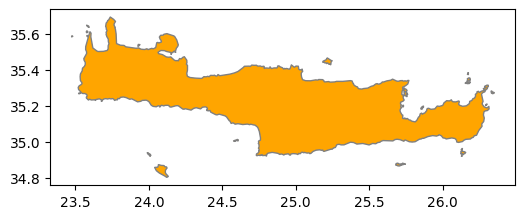

In [10]:
greece_cm_gdf.plot(facecolor="none", edgecolor='grey', figsize=(6,6), color='orange')

In [11]:
greece_cm_lv3 = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\EL_NUTS3.shp",  encoding=enc)
greece_cm_lv3 = greece_cm_lv3[greece_cm_lv3['NUTS_ID'].str.startswith(NUTS2_ID, na=False)]
greece_cm_lv3.reset_index(drop=True, inplace=True) 

In [12]:
greece_cm_lv3.head()

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,CNTR_NAME,geometry
0,EL431,EL,Irakleio,Ηράκλειο,2.0,2,1,Greece,"MULTIPOLYGON (((25.49070 35.29833, 25.49187 35..."
1,EL434,EL,Chania,Χανιά,2.0,2,1,Greece,"MULTIPOLYGON (((24.31741 35.35377, 24.32346 35..."
2,EL432,EL,Lasithi,Λασίθι,2.0,3,1,Greece,"MULTIPOLYGON (((26.35266 35.26980, 26.34043 35..."
3,EL433,EL,Rethymni,Ρέθυμνο,3.0,3,1,Greece,"MULTIPOLYGON (((24.92800 35.40691, 24.92626 35..."


In [13]:
greece_cm_lv3 = greece_cm_lv3.to_crs(epsg=4326)
greece_cm_lv3.drop(columns=['CNTR_CODE', 'NUTS_NAME', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE', 'CNTR_NAME'], inplace=True)

greece_cm_lv3.rename(columns={'NUTS_ID': 'div3_code',
                              'NAME_LATN': 'div3_name'}, inplace=True)

greece_cm_lv3['div3_name'] = greece_cm_lv3['div3_name'].str.lower()
greece_cm_lv3['div3_name'] = greece_cm_lv3['div3_name'].apply(lambda x : remove_accents(x))

greece_cm_lv3['div0_name'] = 'ellada'
greece_cm_lv3['div0_code'] = 'EL'
greece_cm_lv3['div1_name'] = 'nisia aigaiou kriti'
greece_cm_lv3['div1_code'] = 'EL4'
greece_cm_lv3['div2_name'] = 'kriti'
greece_cm_lv3['div2_code'] = 'EL43'

In [14]:
greece_cm_lv3 = greece_cm_lv3[['div0_code', 'div0_name',
                               'div1_code', 'div1_name',
                               'div2_code', 'div2_name',
                               'div3_code', 'div3_name',
                               'geometry']].copy()

In [15]:
greece_cm_lv3

,div0_code,div0_name,div1_code,div1_name,div2_code,div2_name,div3_code,div3_name,geometry
0,EL,ellada,EL4,nisia aigaiou kriti,EL43,kriti,EL431,irakleio,"MULTIPOLYGON (((25.49070 35.29833, 25.49187 35..."
1,EL,ellada,EL4,nisia aigaiou kriti,EL43,kriti,EL434,chania,"MULTIPOLYGON (((24.31741 35.35377, 24.32346 35..."
2,EL,ellada,EL4,nisia aigaiou kriti,EL43,kriti,EL432,lasithi,"MULTIPOLYGON (((26.35266 35.26980, 26.34043 35..."
3,EL,ellada,EL4,nisia aigaiou kriti,EL43,kriti,EL433,rethymni,"MULTIPOLYGON (((24.92800 35.40691, 24.92626 35..."


<Axes: >

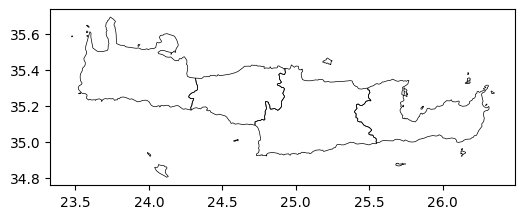

In [16]:
greece_cm_lv3.plot(facecolor="none", edgecolor='black', lw=0.5, figsize=(6,6), color='none')

In [17]:
greece_cm_lv4 = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\old\el_lau1.shp",  encoding=enc)
process_greek(greece_cm_lv4, 'NAME')
greece_cm_lv4_buffered = greece_cm_lv4.copy()
greece_cm_lv4_buffered = greece_cm_lv4_buffered.to_crs("EPSG:3035") 
greece_cm_lv4_buffered["geometry"] = greece_cm_lv4_buffered.geometry.buffer(-500)

In [18]:
greece_cm_lv4_buffered = greece_cm_lv4_buffered[~greece_cm_lv4_buffered.is_empty & greece_cm_lv4_buffered.is_valid]
greece_cm_lv4.shape == greece_cm_lv4_buffered.shape

True

In [19]:
greece_cm_lv4_buffered = greece_cm_lv4_buffered.to_crs("EPSG:4326") 
cm = greece_cm_gdf.geometry.iloc[0]
greece_cm_lv4_buffered = greece_cm_lv4_buffered[greece_cm_lv4_buffered.covered_by(cm)]
greece_cm_lv4_buffered.reset_index(drop=True, inplace=True)

<Axes: >

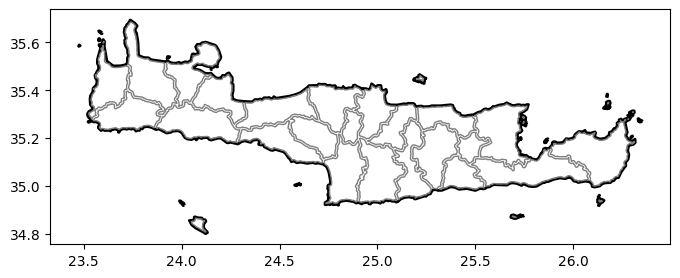

In [20]:
ax = greece_cm_gdf.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=2)
greece_cm_lv4_buffered.plot(facecolor="none", edgecolor='grey', ax=ax, color='none')

In [21]:
kwd_ypes = greece_cm_lv4_buffered.KWD_YPES.to_list()

In [22]:
## This addition is due to missmatching geometries after buffering

## we are manually adding the missing KWD_YPES 9229 Dimos Elefsinas

# kwd_ypes.append('9229')

In [23]:
## Renaming div4_names names based on wrong shapefile names

## kalampakas -> metewrwn

# greece_cm_lv4.loc[greece_cm_lv4['NAME'] == 'καλαμπακας', 'NAME'] = 'μετεωρων'

In [24]:
greece_cm_lv4 = greece_cm_lv4[greece_cm_lv4['KWD_YPES'].isin(kwd_ypes)].copy()
greece_cm_lv4.rename(columns={'KWD_YPES': 'div4_code',
                             'NAME': 'div4_name'}, inplace=True)
greece_cm_lv4 = greek_to_english(greece_cm_lv4, "div4_name")
greece_cm_lv4.reset_index(drop=True, inplace=True)

In [25]:
greece_cm_lv4

,div4_name,div4_code,geometry
0,agioy vasileioy,9314,"MULTIPOLYGON (((24.59029 35.00944, 24.59049 35..."
1,agioy nikolaoy,9310,"MULTIPOLYGON (((25.77267 35.12130, 25.77256 35..."
2,amarioy,9315,"POLYGON ((24.59079 35.29251, 24.59145 35.29239..."
3,anogeion,9316,"POLYGON ((24.84104 35.32344, 24.84514 35.32415..."
4,apokoronoy,9319,"MULTIPOLYGON (((24.19352 35.45597, 24.19363 35..."
5,archanon asteroysion,9302,"POLYGON ((25.18287 35.27491, 25.18461 35.27465..."
6,viannoy,9303,"POLYGON ((25.52999 35.02411, 25.53161 35.02565..."
7,gaydoy,9320,"MULTIPOLYGON (((23.99554 34.93871, 23.99555 34..."
8,gortynas,9304,"POLYGON ((24.94870 35.17913, 24.94971 35.17827..."
9,irakleioy,9305,"POLYGON ((25.13452 35.34328, 25.13449 35.34315..."


<Axes: >

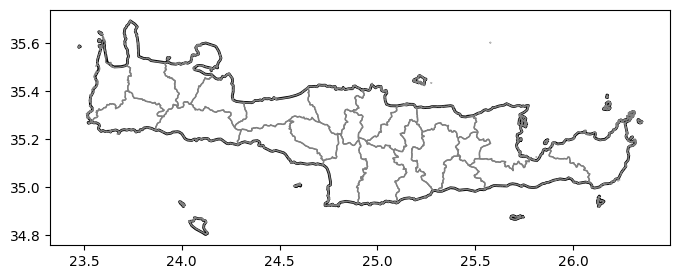

In [26]:
ax = greece_cm_gdf.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=2)
greece_cm_lv4.plot(facecolor="none", edgecolor='grey', ax=ax, color='none')

In [27]:
## GPT Code to enrich lv4 with lv3 attributes

# -------------------------------------------------------------------
# Inputs (already in memory):
#   greece_cm_lv3: polygons with div0..div3 + geometry
#   greece_cm_lv4: polygons with div4 + geometry
# Output:
#   greece_cm_lv4_enriched: lv4 with div0..div3 columns added
# -------------------------------------------------------------------

ADMIN_COLS = [
    "div0_code", "div0_name",
    "div1_code", "div1_name",
    "div2_code", "div2_name",
    "div3_code", "div3_name",
]

# 1) Ensure CRS is set and aligned
if greece_cm_lv3.crs is None or greece_cm_lv4.crs is None:
    raise ValueError(
        "One of the GeoDataFrames has no CRS set. "
        "Set it first with .set_crs(..., inplace=True) before running this."
    )

if greece_cm_lv3.crs != greece_cm_lv4.crs:
    greece_cm_lv4 = greece_cm_lv4.to_crs(greece_cm_lv3.crs)

# 2) Compute inside-points for lv4 (use representative_point to guarantee inside)
lv4 = greece_cm_lv4.copy()
crs_orig = lv4.crs

# For accurate point computations, do it in a metric CRS if current CRS is geographic
if crs_orig.is_geographic:
    # ETRS89 / LAEA Europe (meters) - safe default for Europe/Greece
    lv4_metric = lv4.to_crs(3035)
    lv4_metric["__pt"] = lv4_metric.geometry.representative_point()
    lv4["__pt"] = lv4_metric["__pt"].to_crs(crs_orig)
else:
    lv4["__pt"] = lv4.geometry.representative_point()

lv4_pts = gpd.GeoDataFrame(
    lv4[["div4_code", "div4_name", "__pt"]].copy(),
    geometry="__pt",
    crs=crs_orig,
)

# 3) Spatial join: which lv3 polygon contains the lv4 inside-point?
lv3_for_join = greece_cm_lv3[ADMIN_COLS + ["geometry"]].copy()

# If you suspect invalid geometries in lv3, uncomment:
# lv3_for_join["geometry"] = lv3_for_join.geometry.make_valid()

joined = (
    gpd.sjoin(
        lv4_pts,
        lv3_for_join,
        how="left",
        predicate="within",   # point within polygon
    )
    .drop(columns=["index_right"], errors="ignore")
)

# 4) Merge attributes back onto lv4 polygons
greece_cm_lv4_enriched = (
    greece_cm_lv4
    .merge(joined[["div4_code"] + ADMIN_COLS], on="div4_code", how="left")
)

# 5) Quick diagnostics
missing = greece_cm_lv4_enriched[ADMIN_COLS].isna().any(axis=1)
print(f"Unmatched LV4 rows (no containing LV3 polygon found): {missing.sum()} / {len(missing)}")


Unmatched LV4 rows (no containing LV3 polygon found): 0 / 24


In [28]:
greece_cm_lv4 = greece_cm_lv4_enriched[['div0_name', 'div1_name', 'div2_name', 'div3_name', 'div4_name', 'div0_code', 'div1_code', 'div2_code', 'div3_code', 'div4_code', 'geometry']].copy()

In [29]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

In [30]:
df_grid_cm_d2 = create_grid(empty_gdf, greece_cm_gdf, col_municipal='div0_name', dimension=2)

In [31]:
df_grid_cm_d2.head()

,geometry,centers,div0_name,x,y,resolution_km
0,"POLYGON ((23.56139 35.28749, 23.56139 35.30545...",POINT (23.550451990270368 35.29647001900591),ellada,23.55045,35.29647,2
1,"POLYGON ((23.56139 35.34139, 23.56139 35.35935...",POINT (23.550451990270368 35.35037009380654),ellada,23.55045,35.35037,2
2,"POLYGON ((23.56139 35.35935, 23.56139 35.37732...",POINT (23.550451990270368 35.36833678540677),ellada,23.55045,35.36834,2
3,"POLYGON ((23.58327 35.26952, 23.58327 35.28749...",POINT (23.57233255891904 35.27850332740569),ellada,23.57233,35.27850,2
4,"POLYGON ((23.58327 35.28749, 23.58327 35.30545...",POINT (23.57233255891904 35.29647001900591),ellada,23.57233,35.29647,2


In [32]:
df_grid_cm_d2.shape

(1846, 6)

<Axes: >

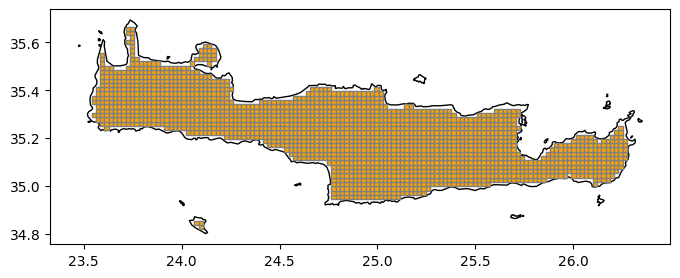

In [33]:
ax = greece_cm_gdf.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=1)
df_grid_cm_d2.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [34]:
df_grid_cm_d2.set_geometry('centers', inplace=True)
df_grid_cm_d2.set_crs(epsg=4326, inplace=True)

,geometry,centers,div0_name,x,y,resolution_km
0,"POLYGON ((23.56139 35.28749, 23.56139 35.30545...",POINT (23.55045 35.29647),ellada,23.55045,35.29647,2
1,"POLYGON ((23.56139 35.34139, 23.56139 35.35935...",POINT (23.55045 35.35037),ellada,23.55045,35.35037,2
2,"POLYGON ((23.56139 35.35935, 23.56139 35.37732...",POINT (23.55045 35.36834),ellada,23.55045,35.36834,2
3,"POLYGON ((23.58327 35.26952, 23.58327 35.28749...",POINT (23.57233 35.27850),ellada,23.57233,35.27850,2
4,"POLYGON ((23.58327 35.28749, 23.58327 35.30545...",POINT (23.57233 35.29647),ellada,23.57233,35.29647,2
...,...,...,...,...,...,...
1841,"POLYGON ((26.27458 35.10782, 26.27458 35.12579...",POINT (26.26364 35.11680),ellada,26.26364,35.11680,2
1842,"POLYGON ((26.27458 35.12579, 26.27458 35.14375...",POINT (26.26364 35.13477),ellada,26.26364,35.13477,2
1843,"POLYGON ((26.27458 35.14375, 26.27458 35.16172...",POINT (26.26364 35.15274),ellada,26.26364,35.15274,2
1844,"POLYGON ((26.27458 35.16172, 26.27458 35.17969...",POINT (26.26364 35.17070),ellada,26.26364,35.17070,2


In [35]:
greece_cm_grid = gpd.sjoin(df_grid_cm_d2, greece_cm_lv4, how='left', op='within')

In [36]:
greece_cm_grid.head()

,geometry,centers,div0_name_left,x,y,resolution_km,index_right,div0_name_right,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code
0,"POLYGON ((23.56139 35.28749, 23.56139 35.30545...",POINT (23.55045 35.29647),ellada,23.55045,35.29647,2,12,ellada,nisia aigaiou kriti,kriti,chania,kissamoy,EL,EL4,EL43,EL434,9322
1,"POLYGON ((23.56139 35.34139, 23.56139 35.35935...",POINT (23.55045 35.35037),ellada,23.55045,35.35037,2,12,ellada,nisia aigaiou kriti,kriti,chania,kissamoy,EL,EL4,EL43,EL434,9322
2,"POLYGON ((23.56139 35.35935, 23.56139 35.37732...",POINT (23.55045 35.36834),ellada,23.55045,35.36834,2,12,ellada,nisia aigaiou kriti,kriti,chania,kissamoy,EL,EL4,EL43,EL434,9322
3,"POLYGON ((23.58327 35.26952, 23.58327 35.28749...",POINT (23.57233 35.27850),ellada,23.57233,35.27850,2,11,ellada,nisia aigaiou kriti,kriti,chania,kantanoy selinoy,EL,EL4,EL43,EL434,9321
4,"POLYGON ((23.58327 35.28749, 23.58327 35.30545...",POINT (23.57233 35.29647),ellada,23.57233,35.29647,2,11,ellada,nisia aigaiou kriti,kriti,chania,kantanoy selinoy,EL,EL4,EL43,EL434,9321


In [37]:
greece_cm_grid.dropna(inplace=True)

In [38]:
final_grid = greece_cm_grid[['x', 'y', 'div0_name_right', 'div1_name', 'div2_name', 'div3_name', 'div4_name', 'div0_code', 'div1_code', 'div2_code', 'div3_code', 'div4_code', 'resolution_km', 'centers', 'geometry']].copy()
final_grid.set_geometry('geometry', inplace=True)
final_grid.rename(columns={'div0_name_right': "div0_name"}, inplace=True)
final_grid.sort_values(by=['x', 'y', 'div4_name'], inplace = True)
final_grid.reset_index(drop=True, inplace=True)

<Axes: >

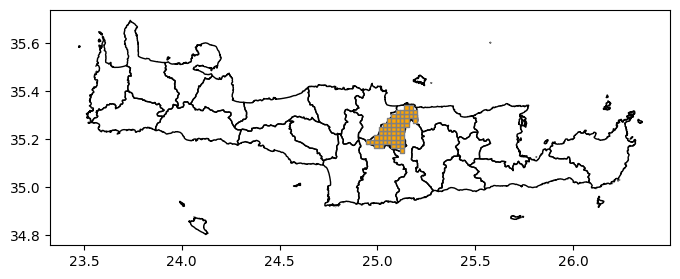

In [39]:
ax = greece_cm_lv4.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=1)
final_grid[final_grid['div4_name'] == 'irakleioy'].plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [40]:
print(f'Shape of final_grid: {final_grid.div4_name.unique().shape}')
print(f'Shape of greece_cm_lv4: {greece_cm_lv4.div4_name.unique().shape}')

Shape of final_grid: (24,)
Shape of greece_cm_lv4: (24,)


In [41]:
diff = list(set(greece_cm_lv4.div4_name.unique().tolist()) - set(final_grid.div4_name.unique().tolist()))
print(f'Difference is: {len(diff)}')
print(f'Missing GIDs are: {diff}') 

Difference is: 0
Missing GIDs are: []


In [42]:
missing_LAUs_d2 = greece_cm_lv4[greece_cm_lv4.div4_name.isin(diff)].copy()
missing_LAUs_d2.reset_index(drop=True, inplace=True)

In [43]:
missing_LAUs_d2

,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,geometry


In [44]:
missing_LAUs_d2["centers"] = missing_LAUs_d2.geometry.centroid

In [45]:
missing_LAUs_d2['resolution_km'] = 1

In [46]:
# ax = missing_LAUs_d2.plot(edgecolor='black', facecolor='none', figsize=(6, 6))
# missing_LAUs_d2['centers'].plot(ax=ax, color='red', markersize=5)

In [47]:
missing_LAUs_d2["x"] = missing_LAUs_d2["centers"].x
missing_LAUs_d2["y"] = missing_LAUs_d2["centers"].y
missing_LAUs_d2 = missing_LAUs_d2[['x', 'y', 'div0_name', 'div1_name', 'div2_name', 'div3_name', 'div4_name', 'div0_code', 'div1_code', 'div2_code', 'div3_code', 'div4_code', 'resolution_km', 'centers', 'geometry']]



In [48]:
missing_LAUs_d2.head()

,x,y,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,resolution_km,centers,geometry


In [49]:
final_grid = pd.concat([final_grid, missing_LAUs_d2], ignore_index=True)

In [50]:
print(f'Shape of final_grid: {final_grid.div4_name.unique().shape}')
print(f'Shape of greece_cm_lv4: {greece_cm_lv4.div4_name.unique().shape}')

Shape of final_grid: (24,)
Shape of greece_cm_lv4: (24,)


In [51]:
final_grid.sort_values(by=['div2_code', 'div3_code', 'div4_code', 'x', 'y'], inplace = True)
final_grid.rename(columns={'x': 'longitude', 'y': 'latitude'}, inplace=True)
final_grid.reset_index(drop=True, inplace=True)
final_grid.drop(columns=['centers'], inplace=True)
final_grid

,longitude,latitude,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,resolution_km,geometry
0,25.08209,35.11680,ellada,nisia aigaiou kriti,kriti,irakleio,archanon asteroysion,EL,EL4,EL43,EL431,9302,2,"POLYGON ((25.09303 35.10782, 25.09303 35.12579..."
1,25.10397,34.95510,ellada,nisia aigaiou kriti,kriti,irakleio,archanon asteroysion,EL,EL4,EL43,EL431,9302,2,"POLYGON ((25.11491 34.94612, 25.11491 34.96409..."
2,25.10397,34.97307,ellada,nisia aigaiou kriti,kriti,irakleio,archanon asteroysion,EL,EL4,EL43,EL431,9302,2,"POLYGON ((25.11491 34.96409, 25.11491 34.98205..."
3,25.10397,35.00900,ellada,nisia aigaiou kriti,kriti,irakleio,archanon asteroysion,EL,EL4,EL43,EL431,9302,2,"POLYGON ((25.11491 35.00002, 25.11491 35.01799..."
4,25.10397,35.02697,ellada,nisia aigaiou kriti,kriti,irakleio,archanon asteroysion,EL,EL4,EL43,EL431,9302,2,"POLYGON ((25.11491 35.01799, 25.11491 35.03595..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1841,24.14123,35.56597,ellada,nisia aigaiou kriti,kriti,chania,chanion,EL,EL4,EL43,EL434,9325,2,"POLYGON ((24.15217 35.55699, 24.15217 35.57495..."
1842,24.14123,35.58394,ellada,nisia aigaiou kriti,kriti,chania,chanion,EL,EL4,EL43,EL434,9325,2,"POLYGON ((24.15217 35.57495, 24.15217 35.59292..."
1843,24.16311,35.53004,ellada,nisia aigaiou kriti,kriti,chania,chanion,EL,EL4,EL43,EL434,9325,2,"POLYGON ((24.17405 35.52105, 24.17405 35.53902..."
1844,24.16311,35.54800,ellada,nisia aigaiou kriti,kriti,chania,chanion,EL,EL4,EL43,EL434,9325,2,"POLYGON ((24.17405 35.53902, 24.17405 35.55699..."


In [ ]:
string_cols = final_grid.select_dtypes(include=['object', 'string']).columns

final_grid[string_cols] = final_grid[string_cols].apply(lambda col: col.map(remove_accents))
final_grid[string_cols] = final_grid[string_cols].apply(lambda col: col.str.replace(r"[,.]", "", regex=True))

In [52]:
if final_grid['div3_code'].isnull().any():
    raise ValueError("div3_code contains NULL values, need rules to handle them.")

# Create a "counter" per div3_code
final_grid['counter'] = final_grid.groupby('div3_code').cumcount() + 1

# Convert counter to hex, padded to 5 digits
final_grid['hex_counter'] = final_grid['counter'].apply(lambda x: format(x, '05X'))

# Final point_code = div3_code + hex_counter
final_grid['point_code'] = final_grid['div3_code'] + final_grid['hex_counter']

# Drop helper columns
final_grid = final_grid.drop(columns=['counter', 'hex_counter'])

In [53]:
final_grid = final_grid[['point_code', 'latitude', 'longitude', 'div0_name', 'div0_code', 'div1_name', 'div1_code', 'div2_name', 'div2_code', 'div3_name', 'div3_code', 'div4_name','div4_code', 'resolution_km', 'geometry']].copy()

<Axes: >

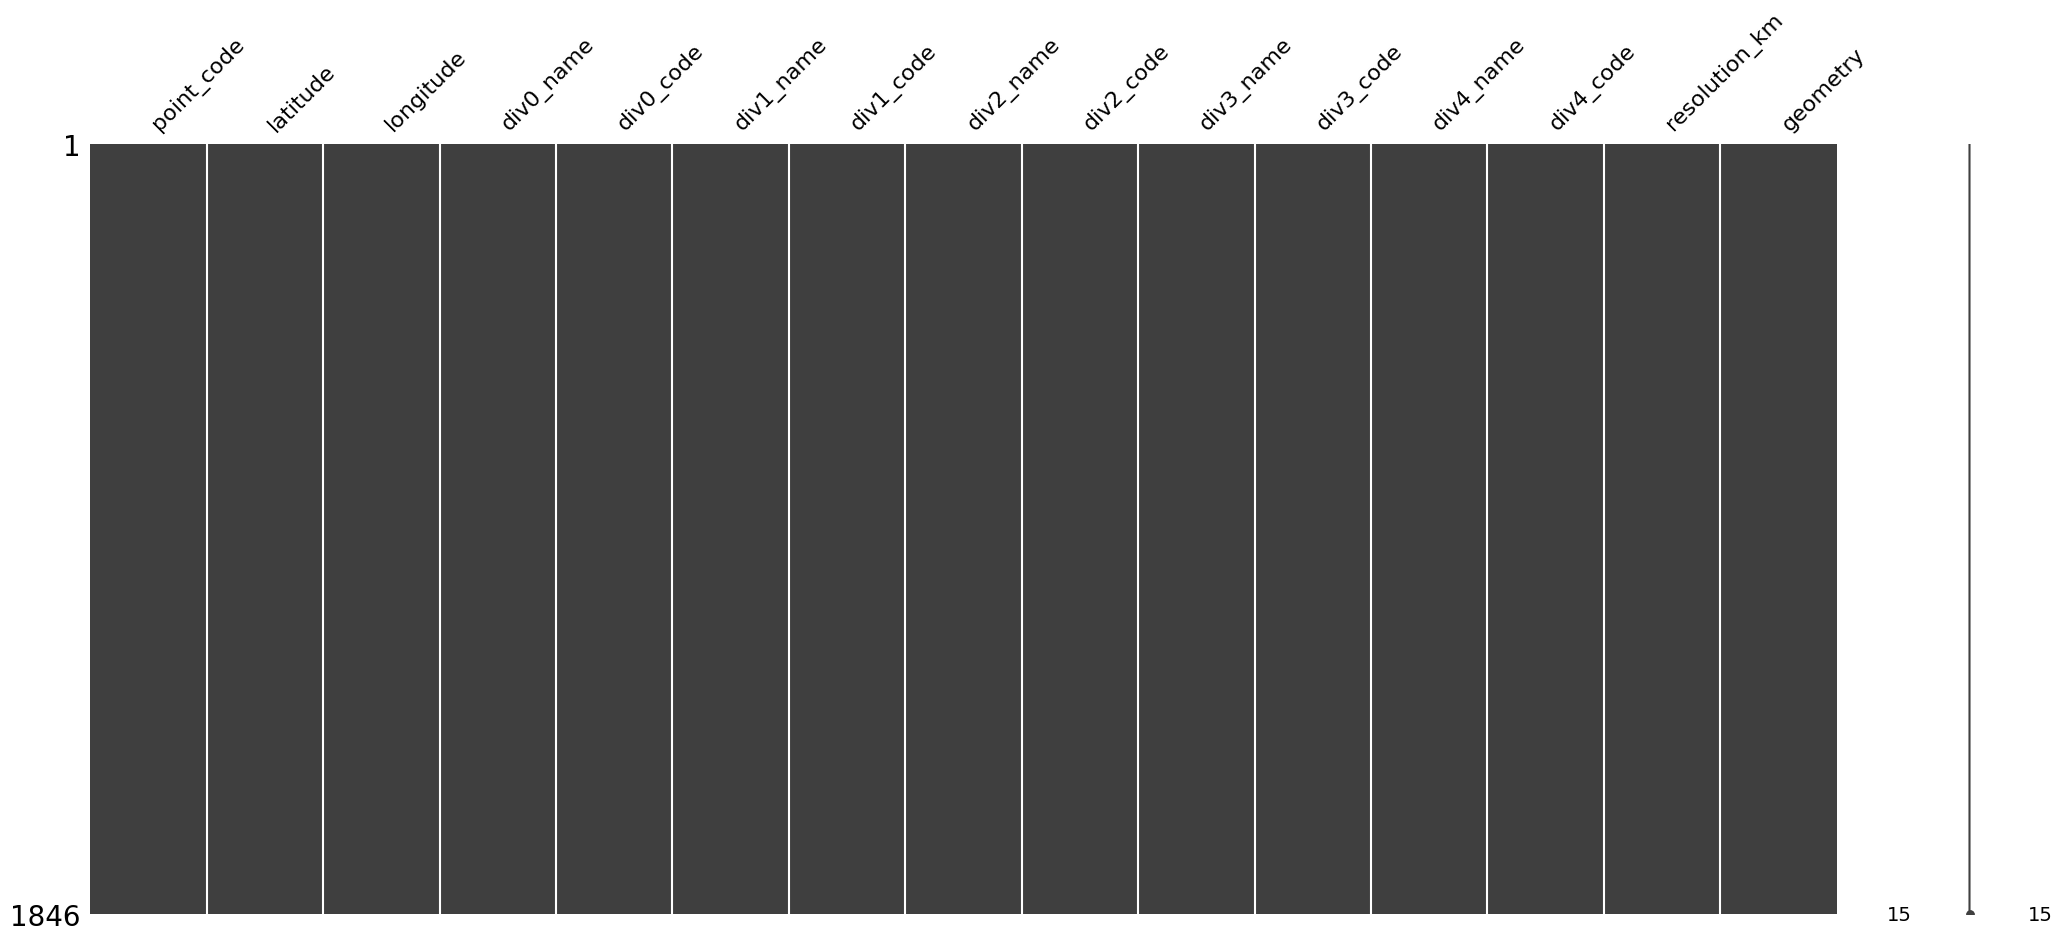

In [54]:
missingno.matrix(final_grid)

In [55]:
final_grid

,point_code,latitude,longitude,div0_name,div0_code,div1_name,div1_code,div2_name,div2_code,div3_name,div3_code,div4_name,div4_code,resolution_km,geometry
0,EL43100001,35.11680,25.08209,ellada,EL,nisia aigaiou kriti,EL4,kriti,EL43,irakleio,EL431,archanon asteroysion,9302,2,"POLYGON ((25.09303 35.10782, 25.09303 35.12579..."
1,EL43100002,34.95510,25.10397,ellada,EL,nisia aigaiou kriti,EL4,kriti,EL43,irakleio,EL431,archanon asteroysion,9302,2,"POLYGON ((25.11491 34.94612, 25.11491 34.96409..."
2,EL43100003,34.97307,25.10397,ellada,EL,nisia aigaiou kriti,EL4,kriti,EL43,irakleio,EL431,archanon asteroysion,9302,2,"POLYGON ((25.11491 34.96409, 25.11491 34.98205..."
3,EL43100004,35.00900,25.10397,ellada,EL,nisia aigaiou kriti,EL4,kriti,EL43,irakleio,EL431,archanon asteroysion,9302,2,"POLYGON ((25.11491 35.00002, 25.11491 35.01799..."
4,EL43100005,35.02697,25.10397,ellada,EL,nisia aigaiou kriti,EL4,kriti,EL43,irakleio,EL431,archanon asteroysion,9302,2,"POLYGON ((25.11491 35.01799, 25.11491 35.03595..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1841,EL434001F3,35.56597,24.14123,ellada,EL,nisia aigaiou kriti,EL4,kriti,EL43,chania,EL434,chanion,9325,2,"POLYGON ((24.15217 35.55699, 24.15217 35.57495..."
1842,EL434001F4,35.58394,24.14123,ellada,EL,nisia aigaiou kriti,EL4,kriti,EL43,chania,EL434,chanion,9325,2,"POLYGON ((24.15217 35.57495, 24.15217 35.59292..."
1843,EL434001F5,35.53004,24.16311,ellada,EL,nisia aigaiou kriti,EL4,kriti,EL43,chania,EL434,chanion,9325,2,"POLYGON ((24.17405 35.52105, 24.17405 35.53902..."
1844,EL434001F6,35.54800,24.16311,ellada,EL,nisia aigaiou kriti,EL4,kriti,EL43,chania,EL434,chanion,9325,2,"POLYGON ((24.17405 35.53902, 24.17405 35.55699..."


In [56]:
final_grid.drop(columns='geometry').to_csv(f'../../data/{NUTS2}/GR_{NUTS2}_Grid_DB.csv', encoding=enc, index = False)
# final_grid.to_file(f'../data/CM_Nord_Grid.shp', encoding = 'utf-8')